<a href="https://colab.research.google.com/github/Fachreza28/pba-task-1a-individual/blob/main/Week2_Scrapping_Apps_Review_MyBCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Scrapping Google Apps Review - eg MyBCA


In [3]:
!pip install google_play_scraper
!pip install textblob
!pip install seaborn
!pip install PySastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.6/210.6 kB 4.3 MB/s eta 0:00:00


In [4]:
from google_play_scraper import app
import pandas as pd
import numpy as np
import sklearn
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns
#from wordcloud import WordCloud
from pathlib import Path
from nltk.corpus import stopwords
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report, accuracy_score

import pickle
import re
import time
import datetime                              # access to %%time, for timing individual notebook cells
import os
from PIL import Image
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

%matplotlib inline
%config InlineBackend.figure_format='retina'

plt.style.use('seaborn-v0_8-dark')
plt.rcParams["figure.figsize"] = (15,10)

In [5]:
# Android App myBCA link from Google Play at
# https://play.google.com/store/apps/details?id=com.bca.mybca.omni.android
# The app ID found in the link after id=com.bca.mybca.omni.android
# The app name on Google Play titled: myBCA

from google_play_scraper import app, Sort, reviews

# Ambil review myBCA
mybca_reviews, _ = reviews(
    'com.bca.mybca.omni.android',
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=50000  # Mengambil 50000 review terbaru
)

In [6]:
# Convert ke DataFrame
df_mybca = pd.DataFrame(mybca_reviews)

# Hapus baris yang content-nya kosong
df_mybca = df_mybca.dropna(subset=['content'])
df_mybca['content'] = df_mybca['content'].astype(str)

# Pilih kolom yang relevan
target_columns = [
    "content",
    "score",
    "thumbsUpCount",
    "reviewCreatedVersion",
    "at",
    "replyContent",
    "repliedAt"
]

existing_columns = [col for col in target_columns if col in df_mybca.columns]
df_mybca = df_mybca[existing_columns]

# Tampilkan data
display(df_mybca.head())

,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,setelah update jadi sangat lemoddddd loadingny...,1,0,2.15.1,2026-03-23 12:57:33,Mohon maaf atas ketidaknyamanannya. Saat ini t...,2026-03-23 13:14:58
1,ok,5,0,2.15.0,2026-03-23 12:56:03,Thank you for the review. We hope that the myB...,2026-03-23 13:17:03
2,parah banget setelah update lemot sekali ini a...,1,0,2.15.1,2026-03-23 12:55:04,Mohon maaf atas ketidaknyamanannya. Saat ini t...,2026-03-23 13:13:55
3,23/7/2026 ini knp setelah di update malah lemo...,1,0,2.15.1,2026-03-23 12:45:21,Mohon maaf atas ketidaknyamanannya. Saat ini t...,2026-03-23 13:12:31
4,"tiap tahun tibatiba diblokir, padahal finger d...",1,0,2.3.1,2026-03-23 12:37:37,Mohon maaf atas ketidaknyamanannya. Jika BCA I...,2026-03-23 13:11:50


## Homework TUGAS 1A

NLP Pipeline:
RAW data (save to csv) lakukan:

* Tokenization
* Lowering
* Stopword Removal
* Lemmatization
* Stemming
* Punctuations Removal
* Expand Contractions
* Spelling Correction
* Rare Words Removal
* Common Words Removal

(save as cleandata.csv)
* Frequent words (n=50,100,1000)
* Frequent Words found (new), contoh: yg, bs, tyt
* ditambahkan di stopwords removal
* Stopwords removal (NLTK, misal case study review hanya dalam Indonesia n=758)


In [7]:
df_mybca

,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,setelah update jadi sangat lemoddddd loadingny...,1,0,2.15.1,2026-03-23 12:57:33,Mohon maaf atas ketidaknyamanannya. Saat ini t...,2026-03-23 13:14:58
1,ok,5,0,2.15.0,2026-03-23 12:56:03,Thank you for the review. We hope that the myB...,2026-03-23 13:17:03
2,parah banget setelah update lemot sekali ini a...,1,0,2.15.1,2026-03-23 12:55:04,Mohon maaf atas ketidaknyamanannya. Saat ini t...,2026-03-23 13:13:55
3,23/7/2026 ini knp setelah di update malah lemo...,1,0,2.15.1,2026-03-23 12:45:21,Mohon maaf atas ketidaknyamanannya. Saat ini t...,2026-03-23 13:12:31
4,"tiap tahun tibatiba diblokir, padahal finger d...",1,0,2.3.1,2026-03-23 12:37:37,Mohon maaf atas ketidaknyamanannya. Jika BCA I...,2026-03-23 13:11:50
...,...,...,...,...,...,...,...
31883,Akhirnya keluar juga,5,0,None,2021-05-04 03:11:07,Terima kasih atas ulasannya. Semoga kami dapat...,2021-05-05 01:54:26
31884,Ayo lengkapin lagi fiturnya,5,0,1.0.0,2021-05-04 02:33:35,"Terima kasih atas saran yang diberikan, untuk ...",2021-05-05 01:59:59
31885,Lebih gampang kelola rekening,5,0,None,2021-05-04 02:05:07,Terima kasih atas ulasannya. Semoga kami dapat...,2021-05-05 02:00:38
31886,"Fiturnya lengkap, 👍👍👍👍",5,1,1.0.0,2021-05-04 00:40:54,Terima kasih atas ulasannya. Semoga fasilitas ...,2021-05-04 14:55:16


In [8]:
df_mybca.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31888 entries, 0 to 31887
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   content               31888 non-null  object        
 1   score                 31888 non-null  int64         
 2   thumbsUpCount         31888 non-null  int64         
 3   reviewCreatedVersion  24702 non-null  object        
 4   at                    31888 non-null  datetime64[ns]
 5   replyContent          31888 non-null  object        
 6   repliedAt             31888 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(3)
memory usage: 1.7+ MB


In [15]:
#We do not need data for column reviewId, userName, userImage so
#we will show only these column
df_analysis = df_mybca.loc[:,["content","score","thumbsUpCount", "reviewCreatedVersion", "at", "replyContent", "repliedAt"]]
df_mybca.loc[:,["content","score","thumbsUpCount", "reviewCreatedVersion", "at", "replyContent", "repliedAt"]]

,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,setelah update jadi sangat lemoddddd loadingnya lama banget...tolong updats lagi biar kaya kmrin kmrin cepet,1,0,2.15.1,2026-03-23 12:57:33,"Mohon maaf atas ketidaknyamanannya. Saat ini tidak terdapat kendala myBCA, terkait kendala yang dialami maka mohon dapat memastikan jaringan yang digunakan dalam kondisi stabil pada saat mengakses...",2026-03-23 13:14:58
1,ok,5,0,2.15.0,2026-03-23 12:56:03,Thank you for the review. We hope that the myBCA application will make your banking transactions easier for you.,2026-03-23 13:17:03
2,parah banget setelah update lemot sekali ini aplikasi !!,1,0,2.15.1,2026-03-23 12:55:04,"Mohon maaf atas ketidaknyamanannya. Saat ini tidak terdapat kendala myBCA, terkait kendala yang dialami maka mohon dapat memastikan jaringan yang digunakan dalam kondisi stabil pada saat mengakses...",2026-03-23 13:13:55
3,23/7/2026 ini knp setelah di update malah lemot? koneksi sy stabil banget. kuota sangat2 memadai...tolong min jelaskan knp?,1,0,2.15.1,2026-03-23 12:45:21,"Mohon maaf atas ketidaknyamanannya. Saat ini tidak terdapat kendala myBCA, terkait kendala yang dialami maka mohon dapat memastikan jaringan yang digunakan dalam kondisi stabil pada saat mengakses...",2026-03-23 13:12:31
4,"tiap tahun tibatiba diblokir, padahal finger dah benar dan password benar, bye my BCA",1,0,2.3.1,2026-03-23 12:37:37,"Mohon maaf atas ketidaknyamanannya. Jika BCA ID milik Bpk/Ibu terblokir maka mohon dapat menelepon Halo BCA 1500888 untuk meminta buka blokir BCA ID yang dimiliki, lalu mengakses menu Reset Passwo...",2026-03-23 13:11:50
...,...,...,...,...,...,...,...
31883,Akhirnya keluar juga,5,0,None,2021-05-04 03:11:07,Terima kasih atas ulasannya. Semoga kami dapat senantiasa memberikan pelayanan yang terbaik kepada nasabah setia BCA.,2021-05-05 01:54:26
31884,Ayo lengkapin lagi fiturnya,5,0,1.0.0,2021-05-04 02:33:35,"Terima kasih atas saran yang diberikan, untuk hal tersebut akan menjadi masukkan kepada kami sebagai bahan evaluasi untuk kedepannya agar mempermudah transaksi Perbankan Bpk/Ibu.",2021-05-05 01:59:59
31885,Lebih gampang kelola rekening,5,0,None,2021-05-04 02:05:07,Terima kasih atas ulasannya. Semoga kami dapat senantiasa memberikan pelayanan yang terbaik kepada nasabah setia BCA.,2021-05-05 02:00:38
31886,"Fiturnya lengkap, 👍👍👍👍",5,1,1.0.0,2021-05-04 00:40:54,Terima kasih atas ulasannya. Semoga fasilitas myBCA semakin mempermudah transaksi Perbankan Bapak/Ibu.,2021-05-04 14:55:16


In [10]:
#Check number of reviews scores
df_mybca['score'].value_counts()

,count
score,
5,13889
1,11496
3,2471
2,2187
4,1845


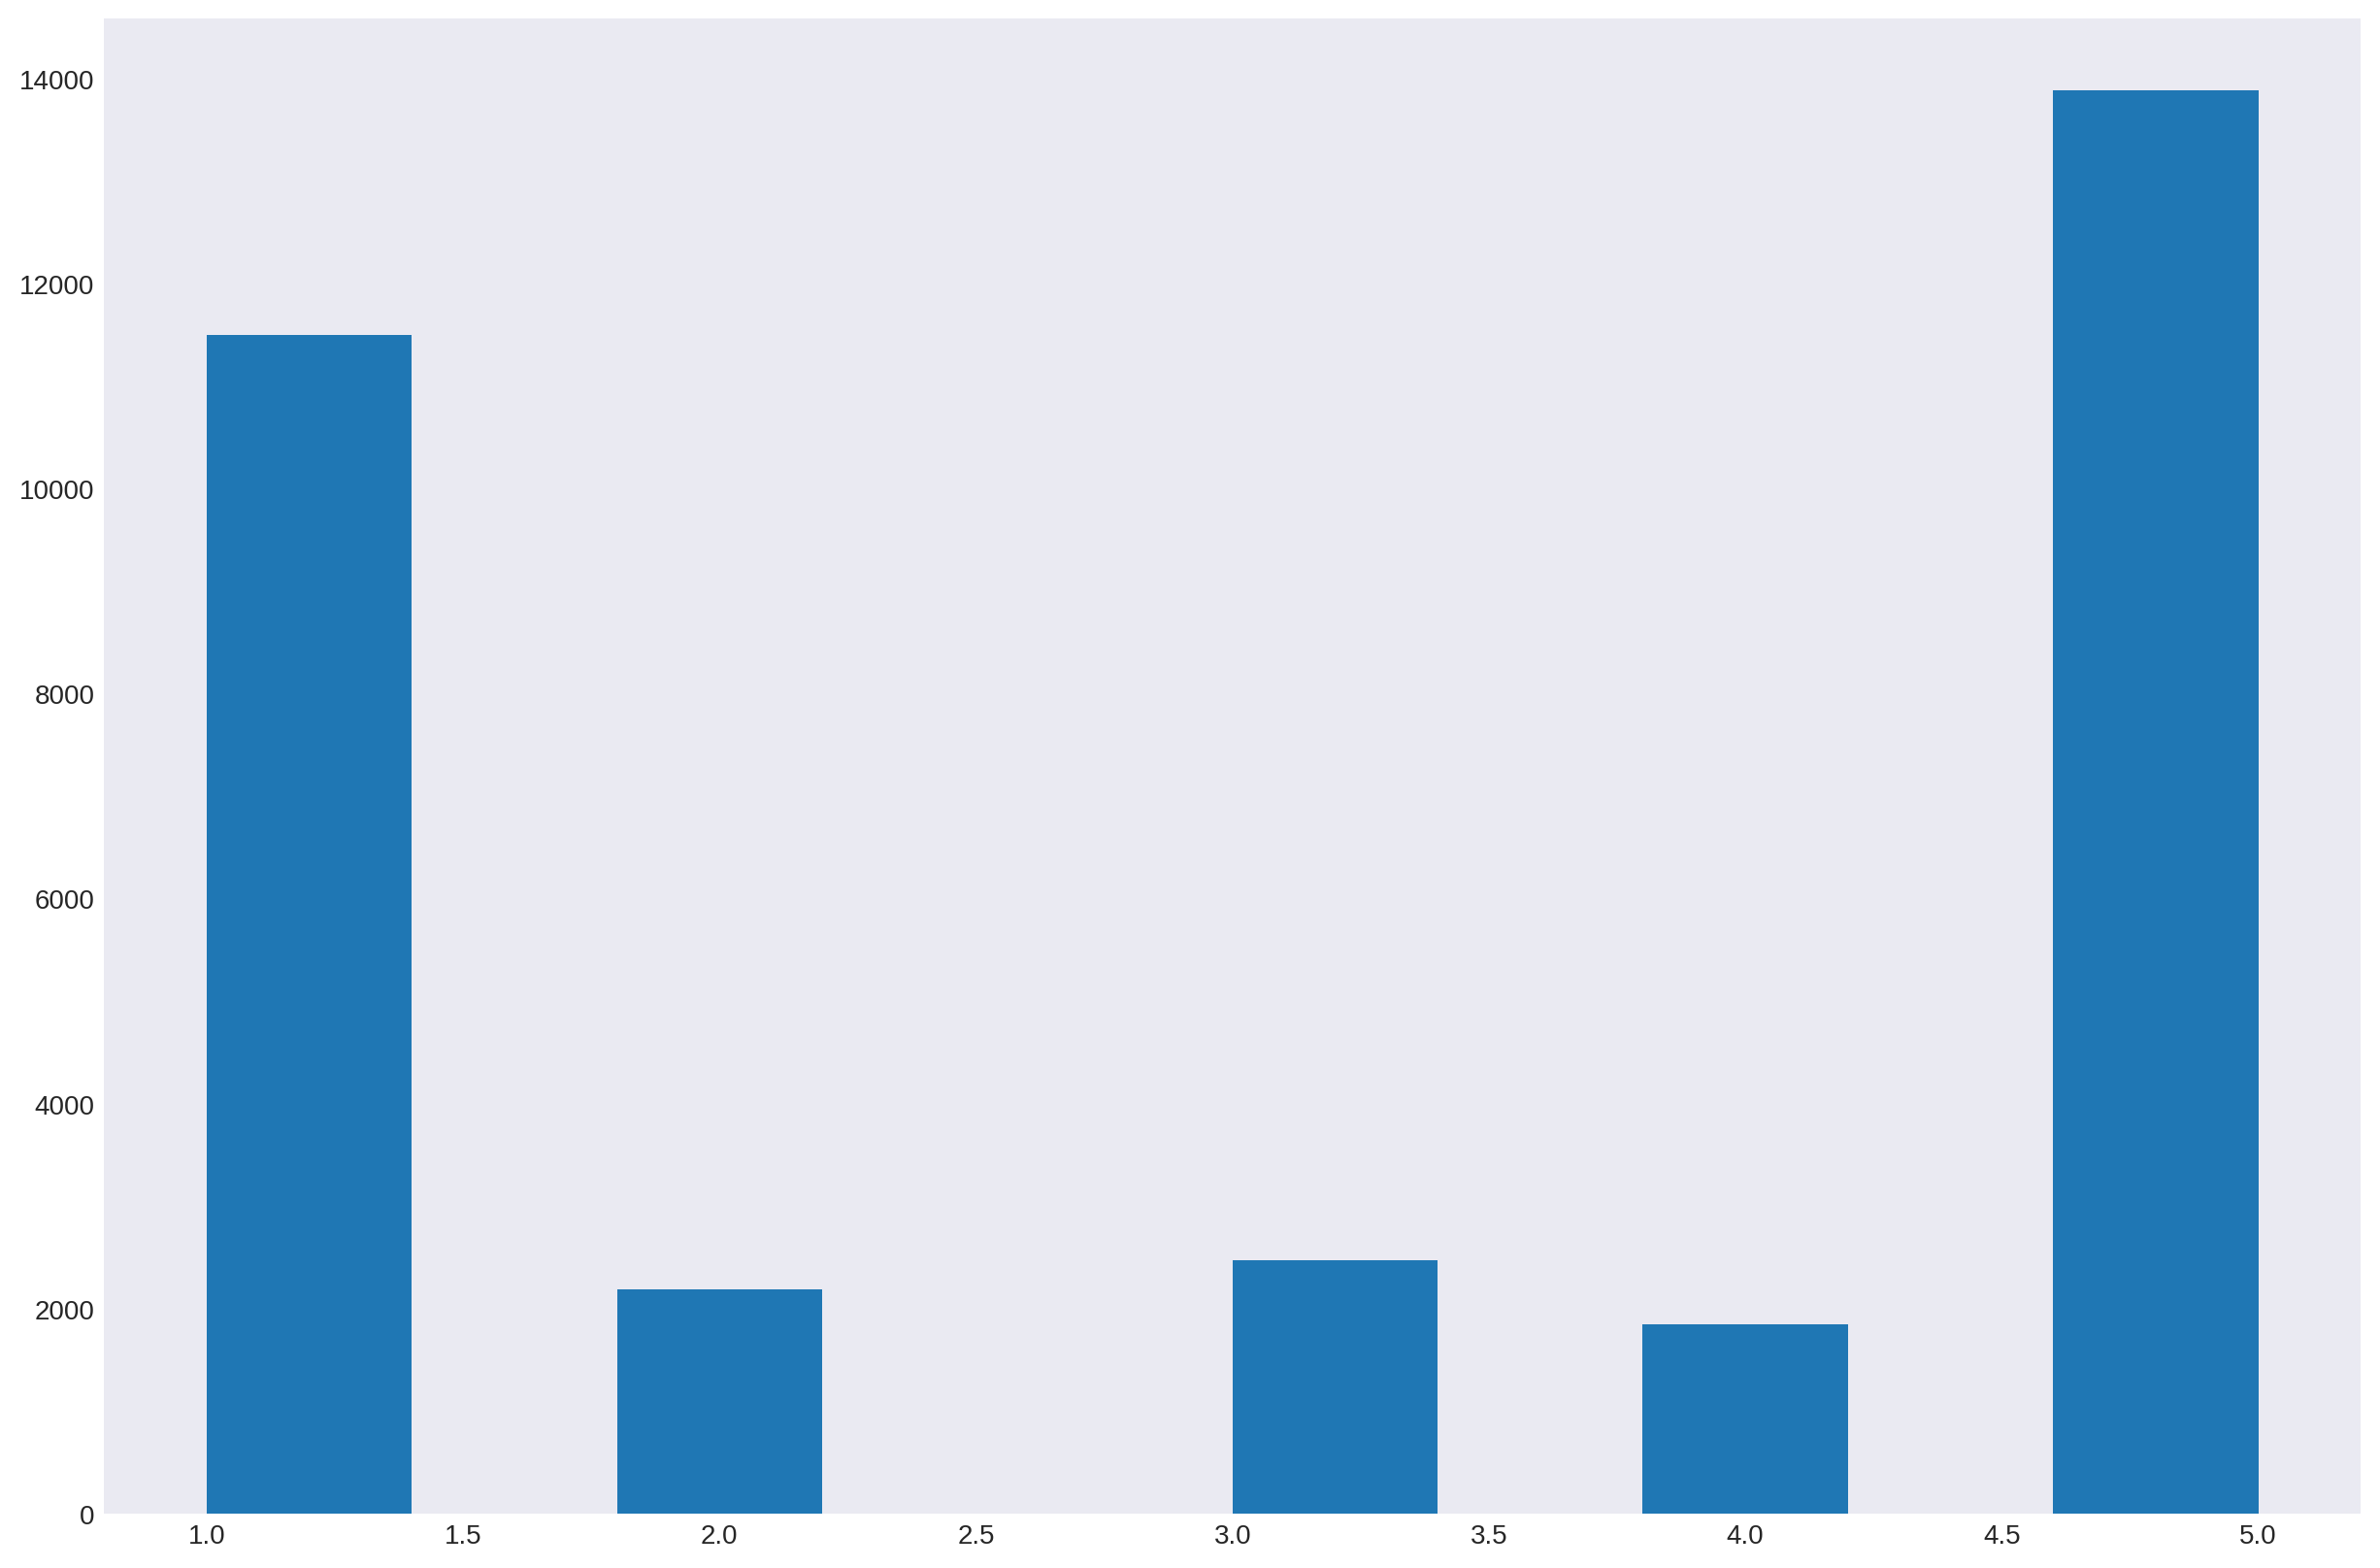

In [11]:
plt.hist(df_mybca['score'])
plt.show()

In [12]:
!pip install emoji

import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", 200)
#from pandas_profiling import ProfileReport
import regex
import nltk
import wordcloud
import textblob

from nltk import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from wordcloud import WordCloud, STOPWORDS
from textblob import TextBlob

import string
import re
import emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 9.5 MB/s eta 0:00:00


In [16]:
#Creating polarity on the column: content (review from the apps) using TextBlob
#Read https://textblob.readthedocs.io/en/dev/quickstart.html

from textblob import TextBlob
# Handle None values in 'content' column by replacing them with empty strings
df_mybca['sentiment_polarity'] = df_mybca['content'].astype(str).apply(lambda x: TextBlob(x).polarity)
df_mybca['sentiment_subjective'] = df_mybca['content'].astype(str).apply(lambda x: TextBlob(x).subjectivity)

In [17]:
df_mybca.loc[:,["content","score","sentiment_polarity", "sentiment_subjective"]]

,content,score,sentiment_polarity,sentiment_subjective
0,setelah update jadi sangat lemoddddd loadingnya lama banget...tolong updats lagi biar kaya kmrin kmrin cepet,1,0.0,0.0
1,ok,5,0.5,0.5
2,parah banget setelah update lemot sekali ini aplikasi !!,1,0.0,0.0
3,23/7/2026 ini knp setelah di update malah lemot? koneksi sy stabil banget. kuota sangat2 memadai...tolong min jelaskan knp?,1,0.0,0.0
4,"tiap tahun tibatiba diblokir, padahal finger dah benar dan password benar, bye my BCA",1,0.0,0.0
...,...,...,...,...
31883,Akhirnya keluar juga,5,0.0,0.0
31884,Ayo lengkapin lagi fiturnya,5,0.0,0.0
31885,Lebih gampang kelola rekening,5,0.0,0.0
31886,"Fiturnya lengkap, 👍👍👍👍",5,0.0,0.0


## Lowercasing

In [19]:
#DATA PREPROCESSING
# Lower casing
# Change the reviews type to string
df_mybca['content'] = df_mybca['content'].astype(str)# Before lowercasing
# Before lowercasing
print(df_mybca['content'][188])
print(df_mybca['content'][1])
print(df_mybca['content'][20100])

BANK BCA INI ANEH SETTIAP BULAN ADA POT ADMIN DAN TERLIHAT DI MUTASI REKENING , TAPI SETIAP BULAN JUGA ADA POTONGAN TIBA2 50 RB YG TIDAK TERCANTUM DI MUTASI REKENING !!!!
ok
saya kasih bintang 5, kalo bintang 7 pusing kepala 😁


In [20]:
#Lowercase all reviews to see the difference
df_mybca['content']= df_mybca['content'].apply(lambda x: x.lower())
print(df_mybca['content'][188])
print(df_mybca['content'][1])
print(df_mybca['content'][20100])

bank bca ini aneh settiap bulan ada pot admin dan terlihat di mutasi rekening , tapi setiap bulan juga ada potongan tiba2 50 rb yg tidak tercantum di mutasi rekening !!!!
ok
saya kasih bintang 5, kalo bintang 7 pusing kepala 😁


##Stopwords Removal
Indonesian Stopwords

In [91]:
#Removing stopwords
#Using nltk
import nltk
from nltk.corpus import stopwords
from nltk import word_tokenize, sent_tokenize
from nltk import FreqDist
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer
from nltk.stem.wordnet import WordNetLemmatizer


from wordcloud import WordCloud, STOPWORDS
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer

from string import punctuation

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [103]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# Get Indonesian stopwords
indonesian_stopwords = stopwords.words('indonesian') + ["yg", "gak", "ga", "aja", "ini", "itu", "dan", "di", "ke"]

# Display first 20 stopwords
print(indonesian_stopwords[:20])

['ada', 'adalah', 'adanya', 'adapun', 'agak', 'agaknya', 'agar', 'akan', 'akankah', 'akhir', 'akhiri', 'akhirnya', 'aku', 'akulah', 'amat', 'amatlah', 'anda', 'andalah', 'antar', 'antara']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [104]:
def freq_words(x, terms=30):
    all_words = ' '.join([text for text in x])
    all_words = all_words.split()

    fdist = FreqDist(all_words)
    words_df = pd.DataFrame({
        'word': list(fdist.keys()),
        'count': list(fdist.values())
    })

    d = words_df.nlargest(columns="count", n=terms)

    plt.figure(figsize=(20,5))
    sns.barplot(data=d, x="word", y="count")
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

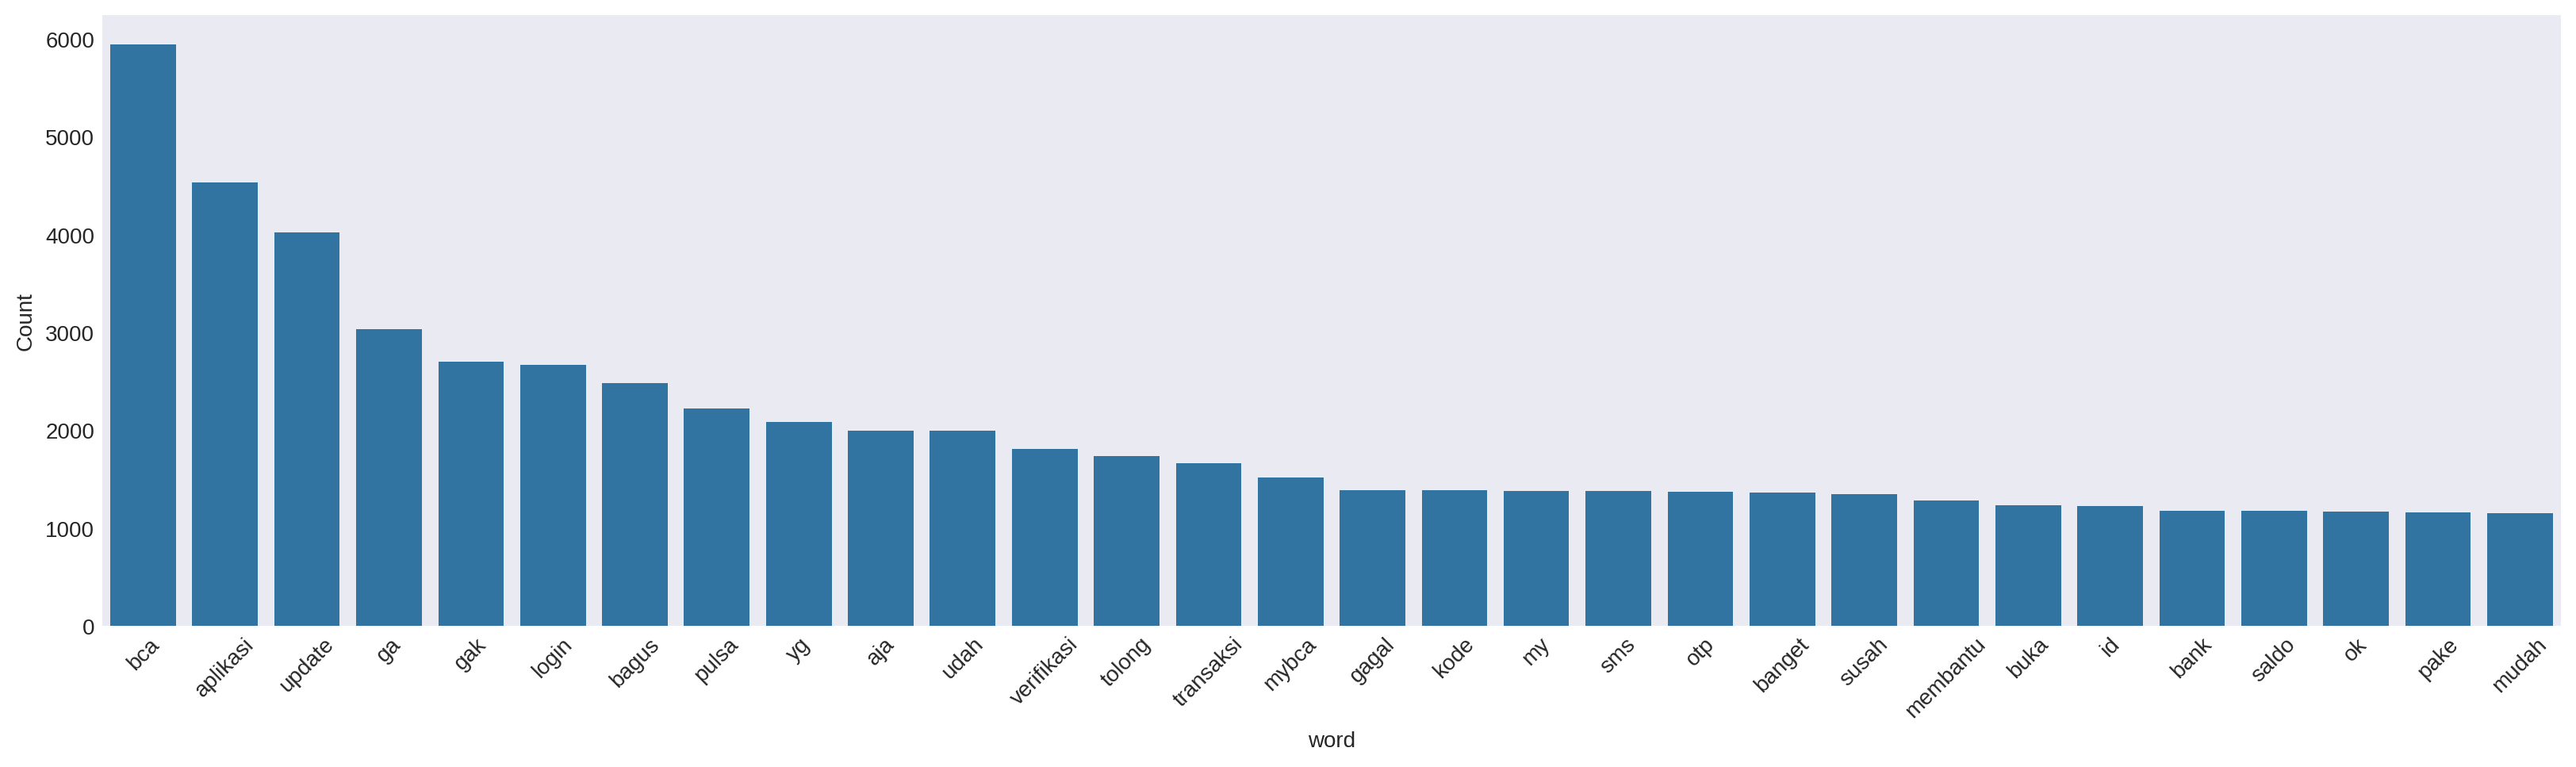

In [105]:
freq_words(df_mybca['content'])

In [106]:
#check if there is any special character
alphabet = string.ascii_letters+string.punctuation
print(df_mybca.content.str.strip(alphabet).astype(bool).any())

extracted_emojis=[]

def extract_emojis(s):
    expe = re.compile('[\U00010000-\U0010ffff]', flags=re.UNICODE)
    return expe.findall(s)

for y in df_mybca['content']:
    extracted_emojis.append(str(extract_emojis(y)))

print(extracted_emojis[:10]) # Print sample

True
['[]', '[]', '[]', '[]', '[]', '[]', '[]', "['😓', '😓']", '[]', '[]']


In [107]:
#edited from https://www.tensorscience.com/nlp/sentiment-analysis-tutorial-in-python-classifying-reviews-on-movies-and-products
df_mybca['wordCount'] = df_mybca['content'].apply(lambda x: len(x.split()))

df_mybca['uppercaseCharCount'] = df_mybca['content'].apply(
    lambda x: sum(1 for char in x if char.isupper())
)

df_mybca['specialCharCount'] = df_mybca['content'].apply(
    lambda x: sum(1 for char in x if char in string.punctuation)
)

In [108]:
df_mybca.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","wordCount","uppercaseCharCount","specialCharCount"]]

,content,score,sentiment_polarity,sentiment_subjective,wordCount,uppercaseCharCount,specialCharCount
0,update lemoddddd loadingnya banget...tolong updats biar kaya kmrin kmrin cepet,1,0.0,0.0,10,0,3
1,ok,5,0.5,0.5,1,0,0
2,parah banget update lemot aplikasi !!,1,0.0,0.0,6,0,2
3,23/7/2026 knp update lemot? koneksi sy stabil banget. kuota sangat2 memadai...tolong min knp?,1,0.0,0.0,13,0,8
4,"tahun tibatiba diblokir, finger dah password benar, bye my bca",1,0.0,0.0,10,0,2
...,...,...,...,...,...,...,...
31883,,5,0.0,0.0,0,0,0
31884,ayo lengkapin fiturnya,5,0.0,0.0,3,0,0
31885,gampang kelola rekening,5,0.0,0.0,3,0,0
31886,"fiturnya lengkap, 👍👍👍👍",5,0.0,0.0,3,0,1


In [109]:
#Add a column name polarity_rating from changing the score of the review into 3 labels: Pos, Negative Neutral
df_mybca['sentiment_rating'] = df_mybca['score'].apply(
    lambda x: 'Positive' if x > 3 else ('Neutral' if x == 3 else 'Negative')
)

In [110]:
df_mybca.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","sentiment_rating"]]

,content,score,sentiment_polarity,sentiment_subjective,sentiment_rating
0,update lemoddddd loadingnya banget...tolong updats biar kaya kmrin kmrin cepet,1,0.0,0.0,Negative
1,ok,5,0.5,0.5,Positive
2,parah banget update lemot aplikasi !!,1,0.0,0.0,Negative
3,23/7/2026 knp update lemot? koneksi sy stabil banget. kuota sangat2 memadai...tolong min knp?,1,0.0,0.0,Negative
4,"tahun tibatiba diblokir, finger dah password benar, bye my bca",1,0.0,0.0,Negative
...,...,...,...,...,...
31883,,5,0.0,0.0,Positive
31884,ayo lengkapin fiturnya,5,0.0,0.0,Positive
31885,gampang kelola rekening,5,0.0,0.0,Positive
31886,"fiturnya lengkap, 👍👍👍👍",5,0.0,0.0,Positive


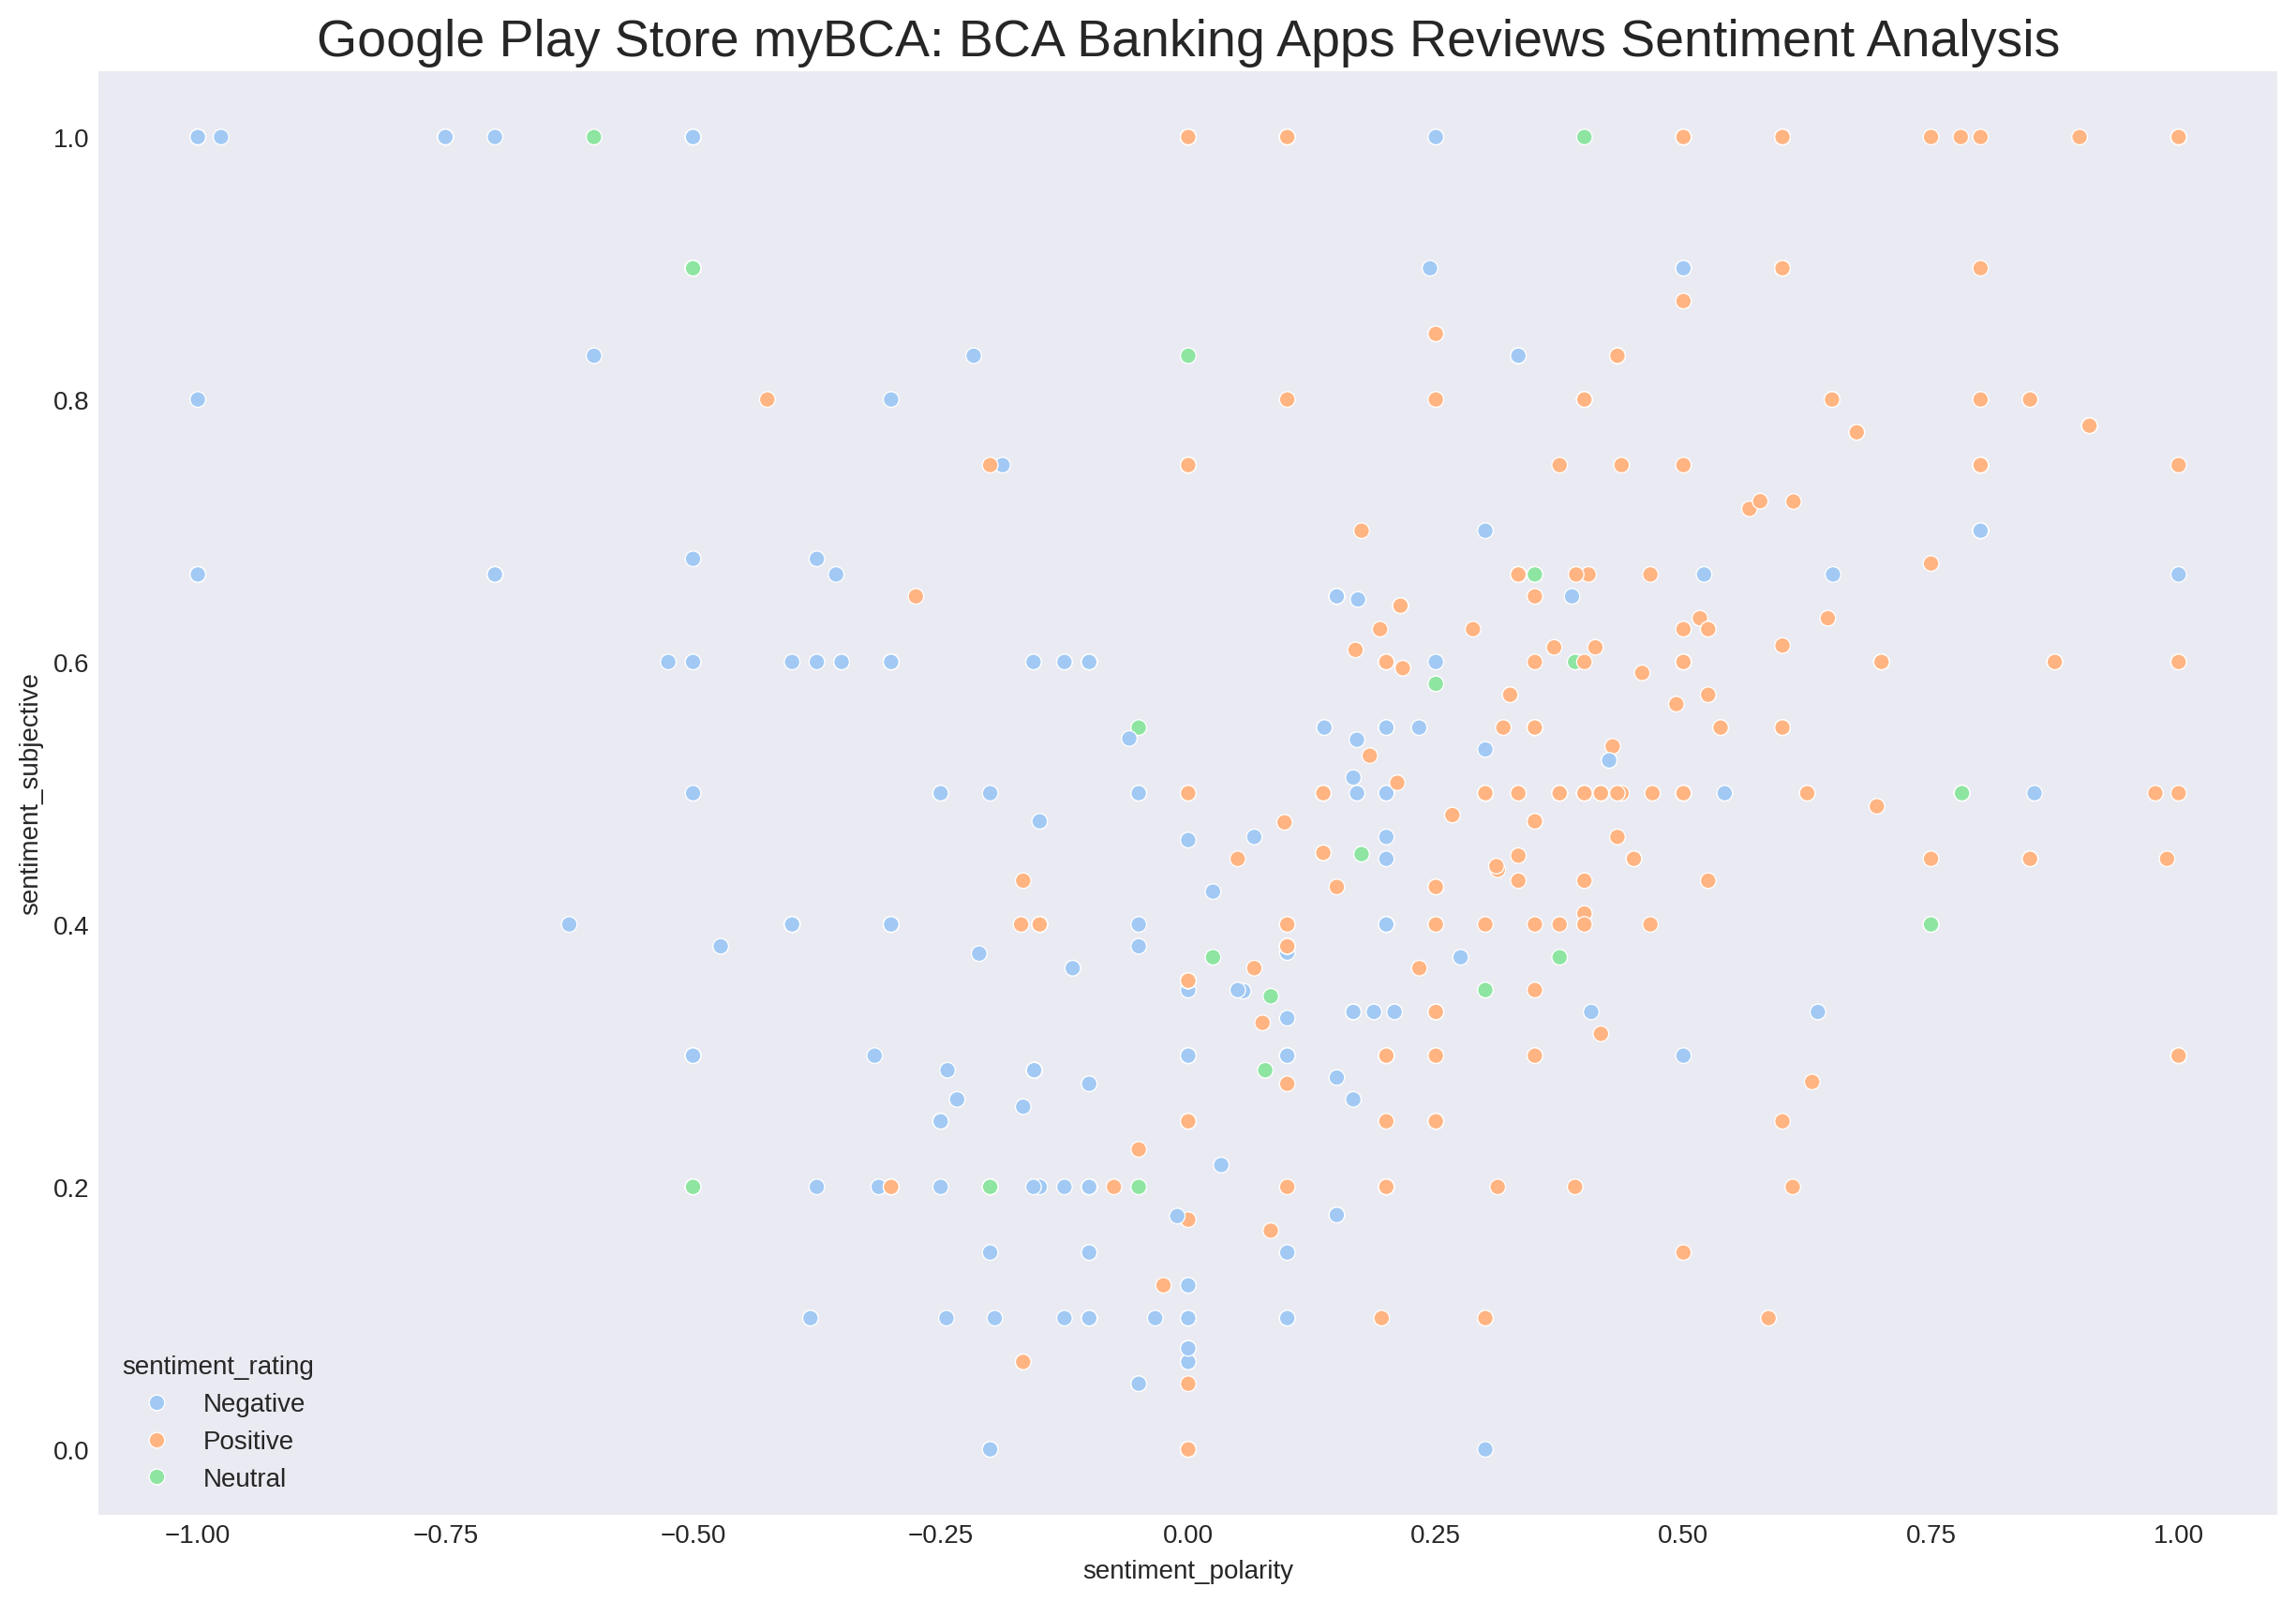

In [111]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))
# Specify x and y using the 'x' and 'y' parameters within sns.scatterplot
sns.scatterplot(x=df_mybca['sentiment_polarity'], y=df_mybca['sentiment_subjective'],
                hue=df_mybca['sentiment_rating'], edgecolor='white', palette="pastel")
plt.title("Google Play Store myBCA: BCA Banking Apps Reviews Sentiment Analysis", fontsize=20)
plt.show()

In [112]:
# function to plot most frequent terms
def freq_words(x, terms = 30):
  all_words = ' '.join([text for text in x])
  all_words = all_words.split()
  #Import FreqDist from nltk.probability
  from nltk.probability import FreqDist
  fdist = FreqDist(all_words)
  words_df = pd.DataFrame({'word':list(fdist.keys()), 'count':list(fdist.values())})

  # selecting top 20 most frequent words
  d = words_df.nlargest(columns="count", n = terms)
  plt.figure(figsize=(20,5))
  # Use the 'rainbow' colormap for the bar plot
  ax = sns.barplot(data=d, x= "word", y = "count", palette="rainbow")
  ax.set(ylabel = 'Count')
  plt.show()

In [113]:
from google.colab import files

# 1. Tentukan nama file saja (tanpa path D:\)
filename = 'df_mybca_before_stopwords_sentiment_rating.csv'

# 2. Simpan file ke penyimpanan sementara Colab
df_mybca.to_csv(filename, index=False)
print(f"File berhasil disimpan di cloud sebagai: {filename}")

# 3. Download file tersebut ke laptop kamu (browser akan otomatis mengunduh)
files.download(filename)

File berhasil disimpan di cloud sebagai: df_mybca_before_stopwords_sentiment_rating.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/tmp/ipykernel_2714/2152088084.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=d, x= "word", y = "count", palette="rainbow")


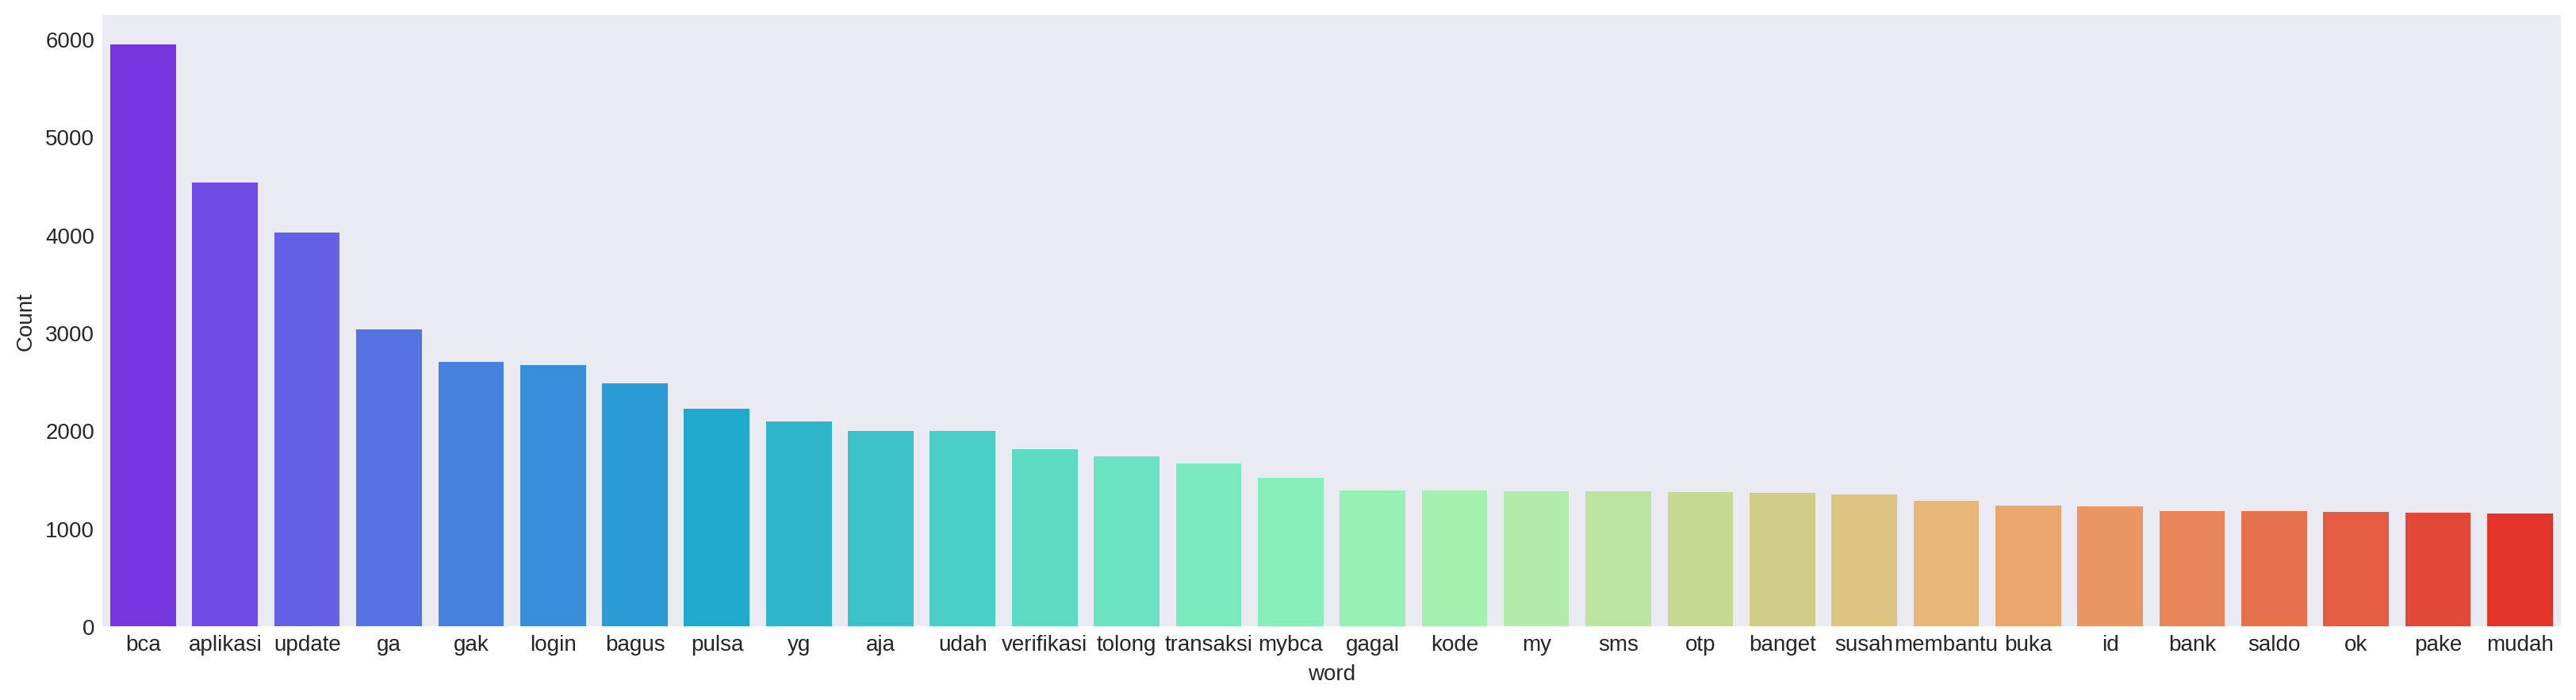

In [114]:
freq_words(df_mybca['content'])

In [115]:
# Install jika belum
!pip install Sastrawi

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Inisialisasi stopword remover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

# Jangan overwrite content → buat kolom baru
df_mybca['text_no_stopwords'] = df_mybca['content'].apply(
    lambda x: stopword_remover.remove(str(x))
)

df_mybca[['content', 'text_no_stopwords']].head()

,content,text_no_stopwords
0,update lemoddddd loadingnya banget...tolong updats biar kaya kmrin kmrin cepet,update lemoddddd loadingnya banget...tolong updats biar kaya kmrin kmrin cepet
1,ok,ok
2,parah banget update lemot aplikasi !!,parah banget update lemot aplikasi !!
3,23/7/2026 knp update lemot? koneksi sy stabil banget. kuota sangat2 memadai...tolong min knp?,23/7/2026 knp update lemot? koneksi sy stabil banget. kuota sangat2 memadai...tolong min knp?
4,"tahun tibatiba diblokir, finger dah password benar, bye my bca","tahun tibatiba diblokir, finger dah password benar, bye my bca"


In [116]:
custom_stopwords = ["yg", "gak", "ga", "aja"]

def remove_stopwords_custom(text):
    text = stopword_remover.remove(text)
    words = text.split()
    words = [w for w in words if w not in custom_stopwords]
    return " ".join(words)

df_mybca['text_no_stopwords'] = df_mybca['content'].apply(remove_stopwords_custom)

In [117]:
import re

df_mybca['text_no_stopwords'] = df_mybca['text_no_stopwords'].apply(
    lambda x: re.sub(r'\s+', ' ', x).strip()
)

In [118]:
df_mybca['wordCount_before'] = df_mybca['content'].apply(lambda x: len(str(x).split()))
df_mybca['wordCount_after'] = df_mybca['text_no_stopwords'].apply(lambda x: len(str(x).split()))

df_mybca[['content', 'text_no_stopwords', 'wordCount_before', 'wordCount_after']].head()

,content,text_no_stopwords,wordCount_before,wordCount_after
0,update lemoddddd loadingnya banget...tolong updats biar kaya kmrin kmrin cepet,update lemoddddd loadingnya banget...tolong updats biar kaya kmrin kmrin cepet,10,10
1,ok,ok,1,1
2,parah banget update lemot aplikasi !!,parah banget update lemot aplikasi !!,6,6
3,23/7/2026 knp update lemot? koneksi sy stabil banget. kuota sangat2 memadai...tolong min knp?,23/7/2026 knp update lemot? koneksi sy stabil banget. kuota sangat2 memadai...tolong min knp?,13,13
4,"tahun tibatiba diblokir, finger dah password benar, bye my bca","tahun tibatiba diblokir, finger dah password benar, bye my bca",10,10


In [119]:
pat = r'\b(?:{})\b'.format('|'.join(stop))
# Note: regex replace ini bisa lambat untuk data besar, tapi dipertahankan sesuai struktur lama
# df_mybca_stopwords['tweet_without_stopwords'] = df_mybca_stopwords['content'].str.replace(pat, '')
df_mybca_stopwords['tweet_without_stopwords'] = df_mybca_stopwords['tweet_without_stopwords'].str.replace(r'\s+', ' ')

In [123]:
nama_file_2 = 'df_mybca_after_stopwords.csv'
df_mybca_stopwords.to_csv(nama_file_2, index=False)

print(f"File berhasil disimpan: {nama_file_2}")

print(f"Sedang mendownload: {nama_file_2} ...")
files.download(nama_file_2)

File berhasil disimpan: df_mybca_after_stopwords.csv
Sedang mendownload: df_mybca_after_stopwords.csv ...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [125]:
#Count after stopwords
#edited from https://www.tensorscience.com/nlp/sentiment-analysis-tutorial-in-python-classifying-reviews-on-movies-and-products
import string

df_mybca_stopwords['wordCount'] = [len(review.split()) for review in df_mybca_stopwords['content']]
df_mybca_stopwords['wordCount_after_stopwords'] = [len(review.split()) for review in df_mybca_stopwords['tweet_without_stopwords']]

In [122]:
display(df_mybca_stopwords.loc[:,["content","score","sentiment_rating","wordCount","tweet_without_stopwords", "wordCount_after_stopwords"]].head())

,content,score,sentiment_rating,wordCount,tweet_without_stopwords,wordCount_after_stopwords
0,update lemoddddd loadingnya banget...tolong updats biar kaya kmrin kmrin cepet,1,Negative,10,update lemoddddd loadingnya banget...tolong updats biar kaya kmrin kmrin cepet,10
1,ok,5,Positive,1,ok,1
2,parah banget update lemot aplikasi !!,1,Negative,6,parah banget update lemot aplikasi !!,6
3,23/7/2026 knp update lemot? koneksi sy stabil banget. kuota sangat2 memadai...tolong min knp?,1,Negative,13,23/7/2026 knp update lemot? koneksi sy stabil banget. kuota sangat2 memadai...tolong min knp?,13
4,"tahun tibatiba diblokir, finger dah password benar, bye my bca",1,Negative,10,"tibatiba diblokir, finger dah password benar, bye my bca",9


In [126]:
# function to plot most frequent terms
def freq_words(x, terms = 30):
  all_words = ' '.join([text for text in x])
  all_words = all_words.split()
  #Import FreqDist from nltk.probability
  from nltk.probability import FreqDist
  fdist = FreqDist(all_words)
  words_df = pd.DataFrame({'word':list(fdist.keys()), 'count':list(fdist.values())})

  # selecting top 20 most frequent words
  d = words_df.nlargest(columns="count", n = terms)
  plt.figure(figsize=(20,5))
  # Use the 'rainbow' colormap for the bar plot
  ax = sns.barplot(data=d, x= "word", y = "count", palette="rainbow")
  ax.set(ylabel = 'Count')
  plt.show()

/tmp/ipykernel_2714/2152088084.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=d, x= "word", y = "count", palette="rainbow")


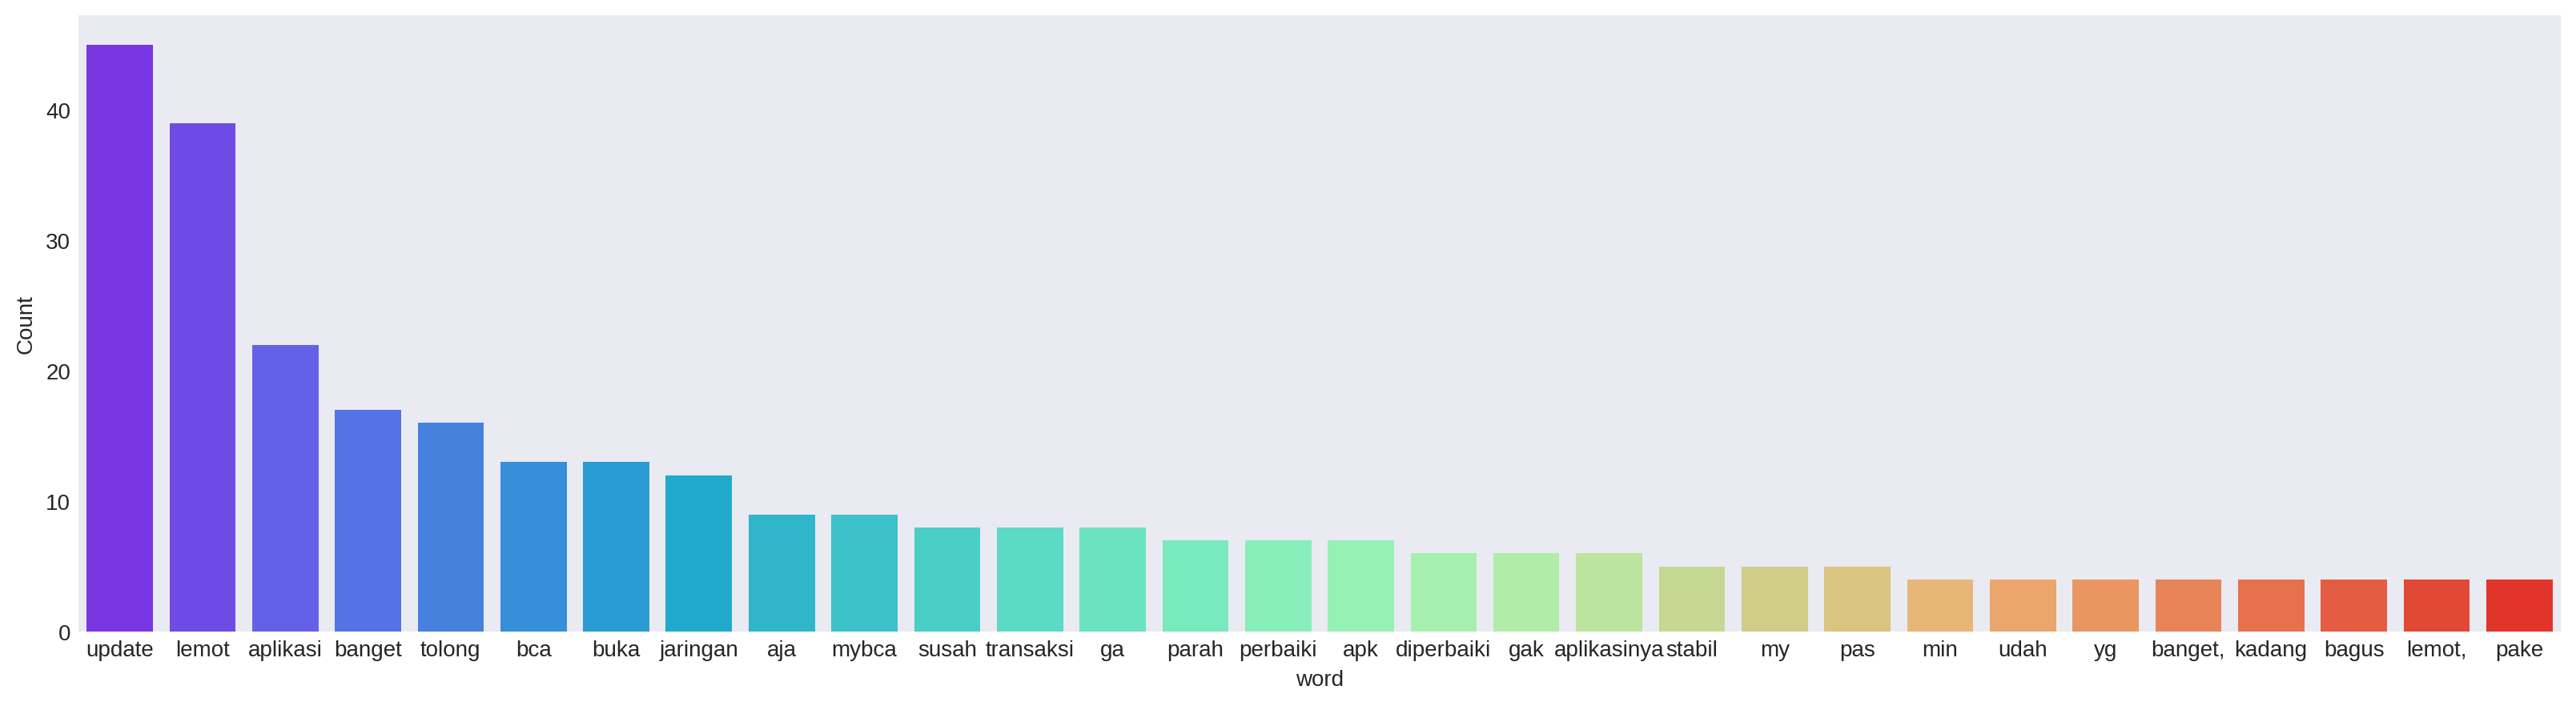

In [127]:
freq_words(df_mybca_stopwords['content'])

In [128]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory_stem = StemmerFactory()
stemmer_indo = factory_stem.create_stemmer()

def stemming(x):
    # Menggunakan stemmer_indo yang sudah di-init di atas
    if x is not None:
        return stemmer_indo.stem(x)
    return x

print("Mulai proses stemming... (Ini akan memakan waktu lama untuk 50k data)")

# Jika mau cepat (demo), pakai ini:
df_mybca['text_stemmed'] = df_mybca['text_no_stopwords'].head(100).apply(stemming)

# Jika mau full data:
# df_mybca['text_stemmed'] = df_mybca['text_no_stopwords'].apply(stemming)

print("Contoh hasil stemming:")
print(df_mybca[['text_no_stopwords', 'text_stemmed']].head())

Mulai proses stemming... (Ini akan memakan waktu lama untuk 50k data)
Contoh hasil stemming:
                                                                               text_no_stopwords  \
0                 update lemoddddd loadingnya banget...tolong updats biar kaya kmrin kmrin cepet   
1                                                                                             ok   
2                                                          parah banget update lemot aplikasi !!   
3  23/7/2026 knp update lemot? koneksi sy stabil banget. kuota sangat2 memadai...tolong min knp?   
4                                 tahun tibatiba diblokir, finger dah password benar, bye my bca   

                                                                          text_stemmed  
0         update lemoddddd loadingnya banget tolong updats biar kaya kmrin kmrin cepet  
1                                                                                   ok  
2                                      

In [129]:
#===BIGRAM https://towardsdatascience.com/text-analysis-basics-in-python-443282942ec5 not yet
#Creating bigram/trigram to search

In [130]:
#DROP NA
df_mybca_stopwords = df_mybca_stopwords.dropna().reset_index(drop=True)

df_mybca_stopwords.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   content                    100 non-null    object 
 1   score                      100 non-null    int64  
 2   sentiment_polarity         100 non-null    float64
 3   sentiment_subjective       100 non-null    float64
 4   sentiment_rating           100 non-null    object 
 5   tweet_without_stopwords    100 non-null    object 
 6   wordCount                  100 non-null    int64  
 7   wordCount_after_stopwords  100 non-null    int64  
 8   tweet_stemmed              100 non-null    object 
dtypes: float64(2), int64(3), object(4)
memory usage: 7.2+ KB


In [131]:
df_mybca_stopwords.loc[:,["content","score","sentiment_rating","wordCount","tweet_without_stopwords", "wordCount_after_stopwords"]]

,content,score,sentiment_rating,wordCount,tweet_without_stopwords,wordCount_after_stopwords
0,update lemoddddd loadingnya banget...tolong updats biar kaya kmrin kmrin cepet,1,Negative,10,update lemoddddd loadingnya banget...tolong updats biar kaya kmrin kmrin cepet,10
1,ok,5,Positive,1,ok,1
2,parah banget update lemot aplikasi !!,1,Negative,6,parah banget update lemot aplikasi !!,6
3,23/7/2026 knp update lemot? koneksi sy stabil banget. kuota sangat2 memadai...tolong min knp?,1,Negative,13,23/7/2026 knp update lemot? koneksi sy stabil banget. kuota sangat2 memadai...tolong min knp?,13
4,"tahun tibatiba diblokir, finger dah password benar, bye my bca",1,Negative,10,"tibatiba diblokir, finger dah password benar, bye my bca",9
...,...,...,...,...,...,...
95,"apknya lemot akhir"" yha min???",5,Positive,5,"apknya lemot akhir"" yha min???",5
96,mudahan bermanfaat,5,Positive,2,mudahan bermanfaat,2
97,"login pas verif wajah gagal mulu,terus suruh call video cs pas klik ops kesalahan.hadehh gimana si",1,Negative,16,"login pas verif wajah gagal mulu,terus suruh call video cs pas klik ops kesalahan.hadehh gimana si",16
98,gbisa dibuka knp 😭biasanya lncr,1,Negative,5,gbisa dibuka knp 😭biasanya lncr,5
